### Preparação das bases

In [1]:
import pandas as pd
import pandas.io.sql as sqlio
import psycopg2 as ps
import os 
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
conn = ps.connect(
        dbname='ANP',
        user=os.getenv('POSTGRES_USER'),
        password='postgres',
        host='localhost',
        port='5433'
    )


In [3]:
query = """
SELECT * FROM anp.preco_combustivel
"""

In [4]:
df = sqlio.read_sql_query(query, conn)

In [5]:
df.head()

,regiao,estado,municipio,revenda,cnpj,nome_rua,numero_rua,complemento,bairro,cep,produto,data_coleta,valor_venda,unidade_medida,bandeira
0,NE,CE,SOBRAL,ECONOGÁS DO BRASIL DIST. DERIV. DE PET. BIOC. ...,08.775.979/0002-62,RUA TABELIÃO IDELFONSO CAVALCANTI,455,None,CENTRO,62010-000,GASOLINA,2025-01-01,6.29,R$ / litro,RAIZEN
1,NE,CE,SOBRAL,ECONOGÁS DO BRASIL DIST. DERIV. DE PET. BIOC. ...,08.775.979/0002-62,RUA TABELIÃO IDELFONSO CAVALCANTI,455,None,CENTRO,62010-000,GASOLINA ADITIVADA,2025-01-01,6.49,R$ / litro,RAIZEN
2,NE,CE,SOBRAL,ECONOGÁS DO BRASIL DIST. DERIV. DE PET. BIOC. ...,08.775.979/0002-62,RUA TABELIÃO IDELFONSO CAVALCANTI,455,None,CENTRO,62010-000,DIESEL S10,2025-01-01,6.19,R$ / litro,RAIZEN
3,NE,CE,SOBRAL,ECONOGÁS DO BRASIL DIST. DERIV. DE PET. BIOC. ...,08.775.979/0002-62,RUA TABELIÃO IDELFONSO CAVALCANTI,455,None,CENTRO,62010-000,ETANOL,2025-01-01,5.19,R$ / litro,RAIZEN
4,NE,CE,SOBRAL,V.C.EMPREENDIMENTOS LTDA,03.551.935/0002-35,AVENIDA JOSE EUCLIDES FERREIRA GOMES,30,POSTO FLASH,CORACAO DE JESUS,62043-070,GASOLINA,2025-01-01,6.53,R$ / litro,RAIZEN


In [6]:
df.shape

(4657284, 15)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4657284 entries, 0 to 4657283
Data columns (total 15 columns):
 #   Column          Dtype 
---  ------          ----- 
 0   regiao          object
 1   estado          object
 2   municipio       object
 3   revenda         object
 4   cnpj            object
 5   nome_rua        object
 6   numero_rua      object
 7   complemento     object
 8   bairro          object
 9   cep             object
 10  produto         object
 11  data_coleta     object
 12  valor_venda     object
 13  unidade_medida  object
 14  bandeira        object
dtypes: object(15)
memory usage: 533.0+ MB


In [8]:
# transforma a coluna direto no df para datetime
df['data_coleta'] = pd.to_datetime(df['data_coleta'], format='mixed', dayfirst=True, errors='coerce')
df['valor_venda'] = pd.to_numeric(df['valor_venda'], errors='coerce')


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4657284 entries, 0 to 4657283
Data columns (total 15 columns):
 #   Column          Dtype         
---  ------          -----         
 0   regiao          object        
 1   estado          object        
 2   municipio       object        
 3   revenda         object        
 4   cnpj            object        
 5   nome_rua        object        
 6   numero_rua      object        
 7   complemento     object        
 8   bairro          object        
 9   cep             object        
 10  produto         object        
 11  data_coleta     datetime64[ns]
 12  valor_venda     float64       
 13  unidade_medida  object        
 14  bandeira        object        
dtypes: datetime64[ns](1), float64(1), object(13)
memory usage: 533.0+ MB


In [10]:
# verifica se o df possui dados nulos e agrupa por colunas
df.isnull().sum()

regiao                  0
estado                  0
municipio               0
revenda                 0
cnpj                    0
nome_rua                0
numero_rua           1727
complemento       3609498
bairro              10654
cep                     0
produto                 0
data_coleta             0
valor_venda       4232357
unidade_medida          0
bandeira                0
dtype: int64

In [11]:
# seleção de colunas especificas
df_anp = df[['data_coleta', 'regiao', 'estado', 'municipio', 'bandeira', 'produto', 'valor_venda']]

In [12]:
df_anp.head()

,data_coleta,regiao,estado,municipio,bandeira,produto,valor_venda
0,2025-01-01,NE,CE,SOBRAL,RAIZEN,GASOLINA,6.29
1,2025-01-01,NE,CE,SOBRAL,RAIZEN,GASOLINA ADITIVADA,6.49
2,2025-01-01,NE,CE,SOBRAL,RAIZEN,DIESEL S10,6.19
3,2025-01-01,NE,CE,SOBRAL,RAIZEN,ETANOL,5.19
4,2025-01-01,NE,CE,SOBRAL,RAIZEN,GASOLINA,6.53


In [13]:
# adiciona colunas de ano e mes baseando-se na coluna data_coleta, usando a função dt (datetime) para classificar os valores corretamente
df_anp['ano'] = df_anp['data_coleta'].dt.year
df_anp['mes'] = df_anp['data_coleta'].dt.month

In [14]:
df_anp.head()

,data_coleta,regiao,estado,municipio,bandeira,produto,valor_venda,ano,mes
0,2025-01-01,NE,CE,SOBRAL,RAIZEN,GASOLINA,6.29,2025,1
1,2025-01-01,NE,CE,SOBRAL,RAIZEN,GASOLINA ADITIVADA,6.49,2025,1
2,2025-01-01,NE,CE,SOBRAL,RAIZEN,DIESEL S10,6.19,2025,1
3,2025-01-01,NE,CE,SOBRAL,RAIZEN,ETANOL,5.19,2025,1
4,2025-01-01,NE,CE,SOBRAL,RAIZEN,GASOLINA,6.53,2025,1


In [15]:
df_anp.describe().round(2)

,data_coleta,valor_venda,ano,mes
count,4657284,424927.00,4657284.00,4657284.00
mean,2022-10-28 22:28:55.686293504,5.89,2022.37,6.01
min,2020-01-01 00:00:00,2.00,2020.00,1.00
25%,2021-08-16 00:00:00,5.59,2021.00,3.00
50%,2022-10-31 00:00:00,6.16,2022.00,6.00
75%,2024-02-27 00:00:00,6.49,2024.00,9.00
max,2025-06-30 00:00:00,9.49,2025.00,12.00
std,NaN,0.90,1.56,3.33


### Inicio do Storytelling

Tipos de combustíveis que são comercializados

In [16]:
# visualizando valores únicos
print(f'Os produtos comercializados são: {df_anp.produto.unique()}')

Os produtos comercializados são: ['GASOLINA' 'GASOLINA ADITIVADA' 'DIESEL S10' 'ETANOL' 'DIESEL' 'GNV']


Anos que estão sendo analisados

In [17]:
print(f'Os anos da nossa base: {df_anp.ano.unique()}')

Os anos da nossa base: [2025 2023 2024 2020 2021 2022]


Valores minimos, máximos e médios dos produtos por ano

In [18]:
df_anp_valor = df_anp[['ano', 'produto', 'valor_venda']]

In [19]:
df_anp_valor['valor_venda'] = pd.to_numeric(df_anp_valor['valor_venda'], errors='coerce')

In [20]:
df_anp_valor.groupby(['produto', 'ano']).agg(['min', 'max', 'mean']).round(2)

valor_venda            
                                min   max  mean
produto            ano                         
DIESEL             2020        3.00  5.00  3.46
                   2021        4.00  6.00  4.85
                   2022        5.00  8.00  6.80
                   2023        5.00  7.00  6.20
                   2024        6.00  7.00  6.37
                   2025        5.29  8.33  6.24
DIESEL S10         2020        3.00  4.00  3.58
                   2021        4.00  6.00  4.86
                   2022        5.00  9.00  7.05
                   2023        5.00  9.00  6.33
                   2024        6.00  8.00  6.59
                   2025        5.19  8.99  6.29
ETANOL             2020        3.00  4.00  3.29
                   2021        4.00  6.00  5.02
                   2022        3.00  7.00  5.45
                   2023        3.00  5.00  4.18
                   2024        3.00  5.00  4.18
                   2025        3.19  6.89  4.48
GASOLINA           2020        3.00  5.00  4.60
                   2021        5.00  7.00  6.20
                   2022        5.00  8.00  6.78
                   2023        5.00  7.00  5.75
                   2024        5.00  6.00  5.81
                   2025        4.99  8.99  6.29
GASOLINA ADITIVADA 2020        4.00  5.00  4.33
                   2021        5.00  7.00  6.14
                   2022        5.00  8.00  6.71
                   2023        5.00  7.00  5.69
                   2024        5.00  7.00  5.98
                   2025        5.19  9.49  6.48
GNV                2020        2.00  3.00  2.71
                   2021        3.00  5.00  4.00
                   2022        4.00  6.00  5.50
                   2023         NaN   NaN   NaN
                   2024         NaN   NaN   NaN
                   2025        3.79  6.49  4.81

In [21]:
df_anp_valor_estado = df_anp[['ano', 'produto', 'estado', 'valor_venda']]

In [22]:
df_anp_valor_estado['valor_venda'] = pd.to_numeric(df_anp_valor_estado['valor_venda'], errors='coerce')

In [23]:
df_anp_valor_estado.head()

,ano,produto,estado,valor_venda
0,2025,GASOLINA,CE,6.29
1,2025,GASOLINA ADITIVADA,CE,6.49
2,2025,DIESEL S10,CE,6.19
3,2025,ETANOL,CE,5.19
4,2025,GASOLINA,CE,6.53


In [24]:
df_anp_valor_estado.groupby(['produto', 'ano', 'estado']).agg(['min', 'max', 'mean']).round(2)

valor_venda            
                            min   max  mean
produto ano  estado                        
DIESEL  2020 AC            4.00  4.00  4.00
             AL            3.00  3.00  3.00
             AM            4.00  4.00  4.00
             AP            3.00  4.00  3.50
             BA            3.00  3.00  3.00
...                         ...   ...   ...
GNV     2025 RN            4.59  6.19  4.91
             RS            4.29  5.94  4.75
             SC            4.88  5.54  5.21
             SE            4.90  4.99  4.93
             SP            3.79  5.39  4.69

[928 rows x 3 columns]

Verificar a quantidade de bandeiras por produto/ano

In [25]:
df_anp_bandeira = df_anp[['ano', 'bandeira', 'produto']]

In [26]:
df_anp_bandeira.head()

,ano,bandeira,produto
0,2025,RAIZEN,GASOLINA
1,2025,RAIZEN,GASOLINA ADITIVADA
2,2025,RAIZEN,DIESEL S10
3,2025,RAIZEN,ETANOL
4,2025,RAIZEN,GASOLINA


In [27]:
df_anp_bandeira.groupby(['ano', 'produto']).bandeira.unique()

ano   produto           
2020  DIESEL                [PETROBRAS DISTRIBUIDORA S.A., BRANCA, SABBÁ, ...
      DIESEL S10            [PETROBRAS DISTRIBUIDORA S.A., RODOIL, BRANCA,...
      ETANOL                [BRANCA, PETROBRAS DISTRIBUIDORA S.A., RODOIL,...
      GASOLINA              [SABBÁ, PETROBRAS DISTRIBUIDORA S.A., RODOIL, ...
      GASOLINA ADITIVADA    [PETROBRAS DISTRIBUIDORA S.A., BRANCA, SABBÁ, ...
      GNV                   [PETROBRAS DISTRIBUIDORA S.A., BRANCA, RAIZEN,...
2021  DIESEL                [BRANCA, IPIRANGA, RAIZEN, PETROBRAS DISTRIBUI...
      DIESEL S10            [BRANCA, IPIRANGA, RAIZEN, PETROBRAS DISTRIBUI...
      ETANOL                [BRANCA, PETROBRAS DISTRIBUIDORA S.A., RAIZEN,...
      GASOLINA              [BRANCA, IPIRANGA, RAIZEN, PETROBRAS DISTRIBUI...
      GASOLINA ADITIVADA    [BRANCA, IPIRANGA, RAIZEN, PETROBRAS DISTRIBUI...
      GNV                   [BRANCA, RAIZEN, IPIRANGA, PETROBRAS DISTRIBUI...
2022  DIESEL                [IPIRANGA, 

In [28]:
df_anp_bandeira_estado = df_anp[['ano', 'bandeira', 'produto', 'estado']]

### Visualizações

In [50]:
df_anp['produto'].unique()

array(['GASOLINA', 'GASOLINA ADITIVADA', 'DIESEL S10', 'ETANOL', 'DIESEL',
       'GNV'], dtype=object)

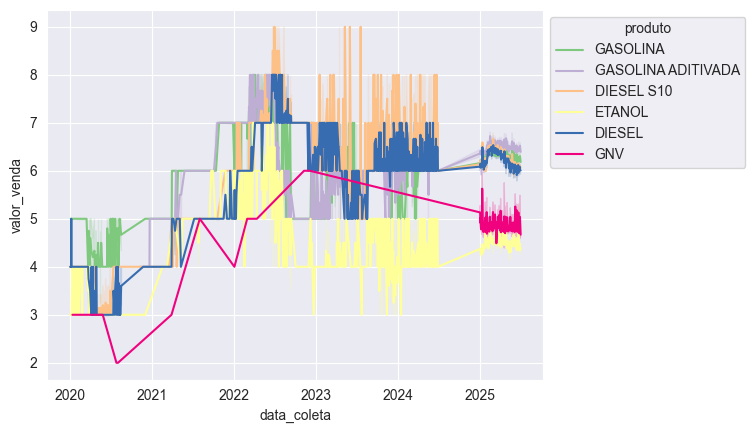

In [51]:
ax = sns.lineplot(data = df_anp, x="data_coleta", y="valor_venda", hue="produto")
sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))

Separando o dataset para entender melhor a base

In [52]:
gasolina_aditivada = df_anp[df['produto']=='GASOLINA ADITIVADA']
gasolina = df_anp[df['produto']=='GASOLINA']
diesel_s10 = df_anp[df['produto']=='DIESEL S10']
diesel = df_anp[df['produto']=='DIESEL']
etanol = df_anp[df['produto']=='ETANOL']
gnv = df_anp[df['produto']=='GNV']

Criando funções para auxiliar o plot dos gráficos

In [53]:
def plotar_boxplot_V2(titulo, labelx, labely, x, y, dataset):
  sns.set_palette('Accent')
  sns.set_style('darkgrid')
  ax = sns.boxplot(x=x, y=y, data=dataset)
  ax.figure.set_size_inches(12,6)
  ax.set_title(titulo, loc='left', fontsize=18)
  ax.set_xlabel(labelx, fontsize=14)
  ax.set_ylabel(labely, fontsize=14)



In [54]:
def plotar_boxplot_geral(y, dataset):
  ax = sns.boxplot(y=y, data=dataset)
  ax.figure.set_size_inches(4,4)

Analisando os combustiveis

Gasolina aditivada

In [55]:
# estatistica básica de cada produto
print('Gasolina Aditivada')
gasolina_aditivada.valor_venda.describe().round(2)

Gasolina Aditivada


count    86501.00
mean         6.48
std          0.42
min          4.00
25%          6.19
50%          6.49
75%          6.69
max          9.49
Name: valor_venda, dtype: float64

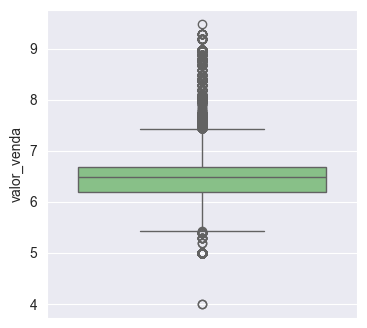

In [56]:
plotar_boxplot_geral('valor_venda', gasolina_aditivada)

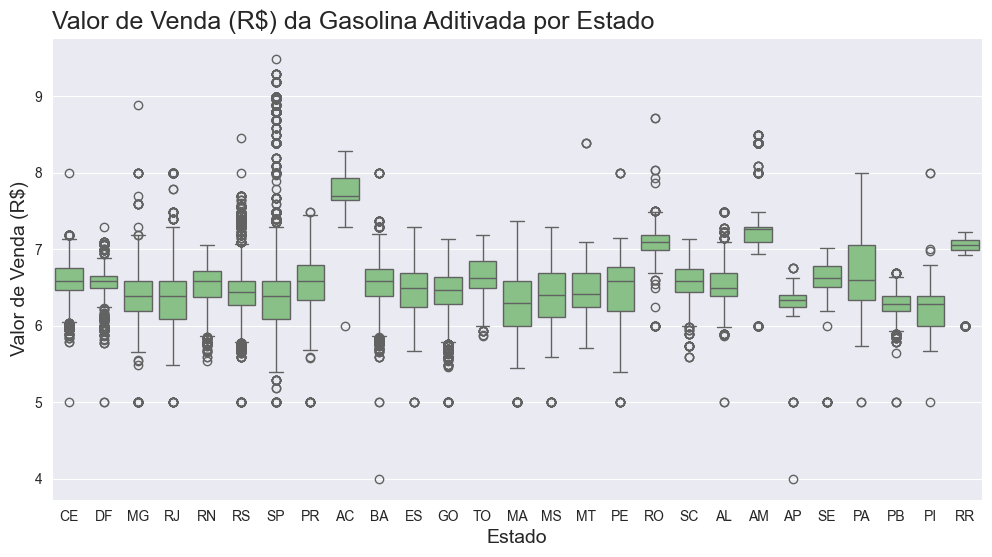

In [57]:
plotar_boxplot_V2('Valor de Venda (R$) da Gasolina Aditivada por Estado',
                  'Estado',
                  'Valor de Venda (R$)',
                  'estado',
                  'valor_venda',
                  gasolina_aditivada)

Gasolina Comum

In [58]:
# estatistica básica de cada produto
print('Gasolina Comum')
gasolina.valor_venda.describe().round(2)

Gasolina Comum


count    111602.00
mean          6.29
std           0.41
min           3.00
25%           5.99
50%           6.28
75%           6.49
max           8.99
Name: valor_venda, dtype: float64

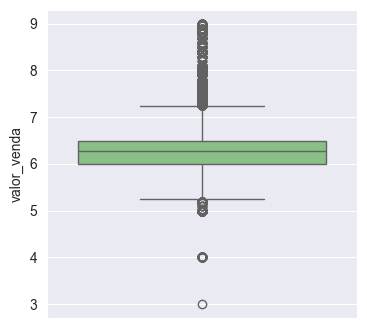

In [59]:
plotar_boxplot_geral('valor_venda', gasolina)

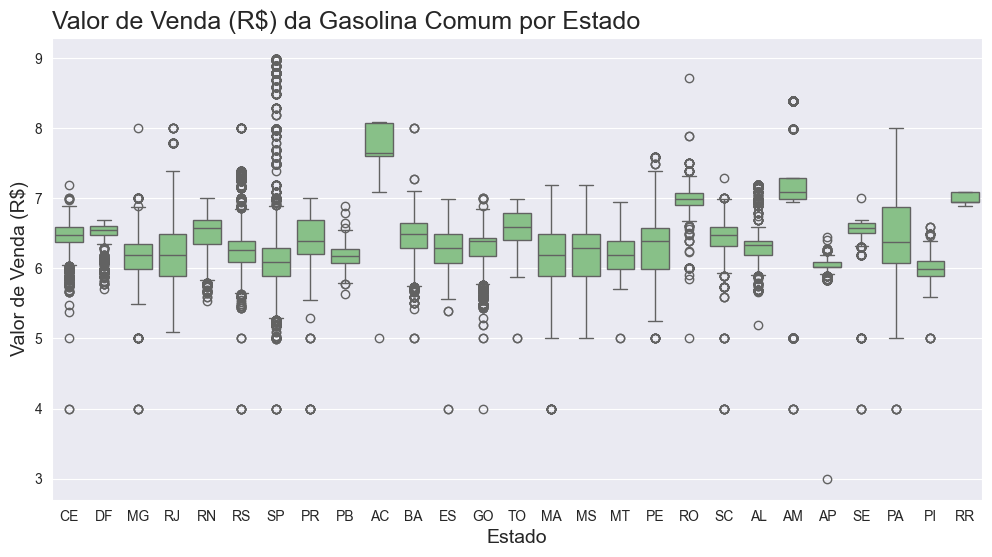

In [60]:
plotar_boxplot_V2('Valor de Venda (R$) da Gasolina Comum por Estado',
                  'Estado',
                  'Valor de Venda (R$)',
                  'estado',
                  'valor_venda',
                  gasolina)

Etanol

In [61]:
# estatistica básica de cada produto
print('Etanol')
etanol.valor_venda.describe().round(2)

Etanol


count    93394.00
mean         4.48
std          0.47
min          3.00
25%          4.11
50%          4.47
75%          4.79
max          7.00
Name: valor_venda, dtype: float64

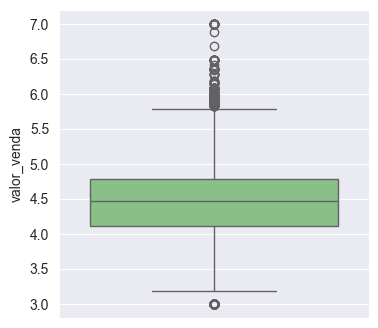

In [62]:
plotar_boxplot_geral('valor_venda', etanol)

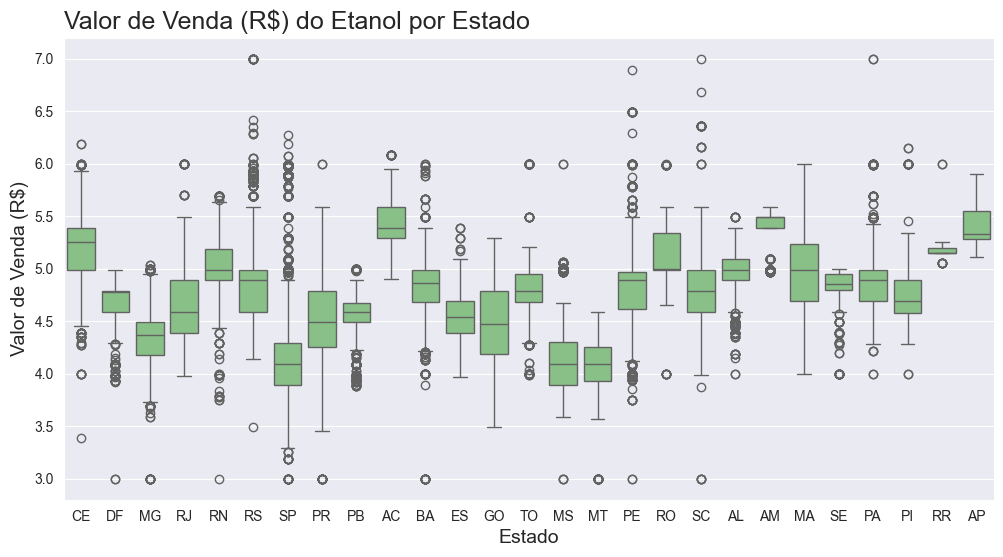

In [63]:
plotar_boxplot_V2('Valor de Venda (R$) do Etanol por Estado',
                  'Estado',
                  'Valor de Venda (R$)',
                  'estado',
                  'valor_venda',
                  etanol)

Diesel S10

In [64]:
# estatistica básica de cada produto
print('Diesel S10')
diesel_s10.valor_venda.describe().round(2)

Diesel S10


count    77120.00
mean         6.29
std          0.45
min          3.00
25%          5.99
50%          6.28
75%          6.49
max          9.00
Name: valor_venda, dtype: float64

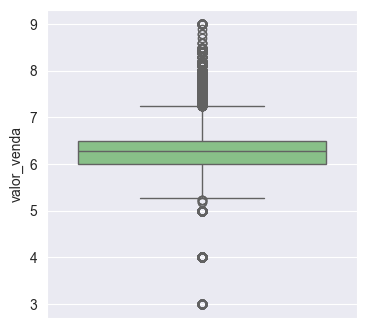

In [65]:
plotar_boxplot_geral('valor_venda', diesel_s10)

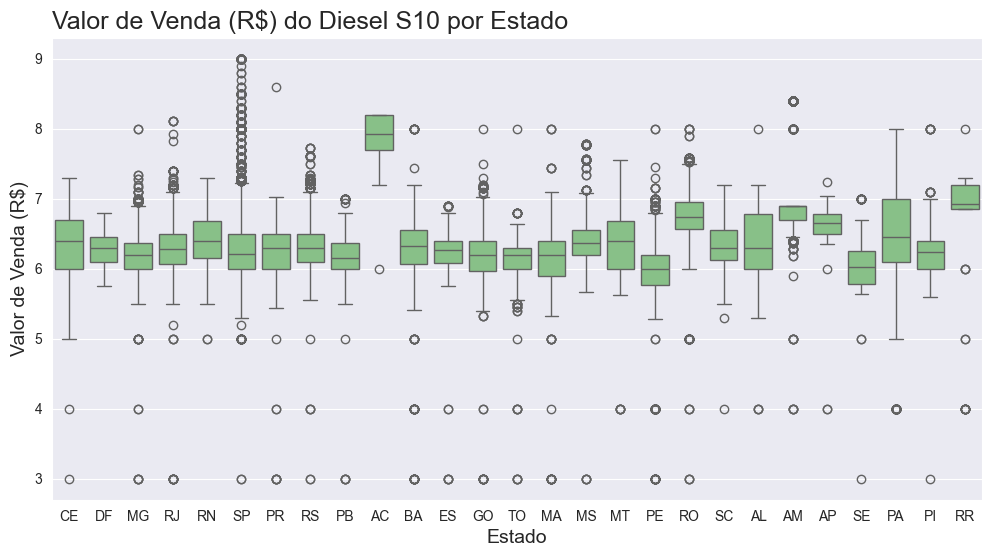

In [66]:
plotar_boxplot_V2('Valor de Venda (R$) do Diesel S10 por Estado',
                  'Estado',
                  'Valor de Venda (R$)',
                  'estado',
                  'valor_venda',
                  diesel_s10)

Diesel

In [67]:
# estatistica básica de cada produto
print('Diesel')
diesel.valor_venda.describe().round(2)

Diesel


count    46785.00
mean         6.23
std          0.45
min          3.00
25%          5.97
50%          6.19
75%          6.46
max          8.33
Name: valor_venda, dtype: float64

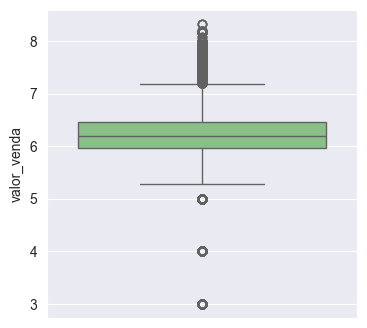

In [68]:
plotar_boxplot_geral('valor_venda', diesel)

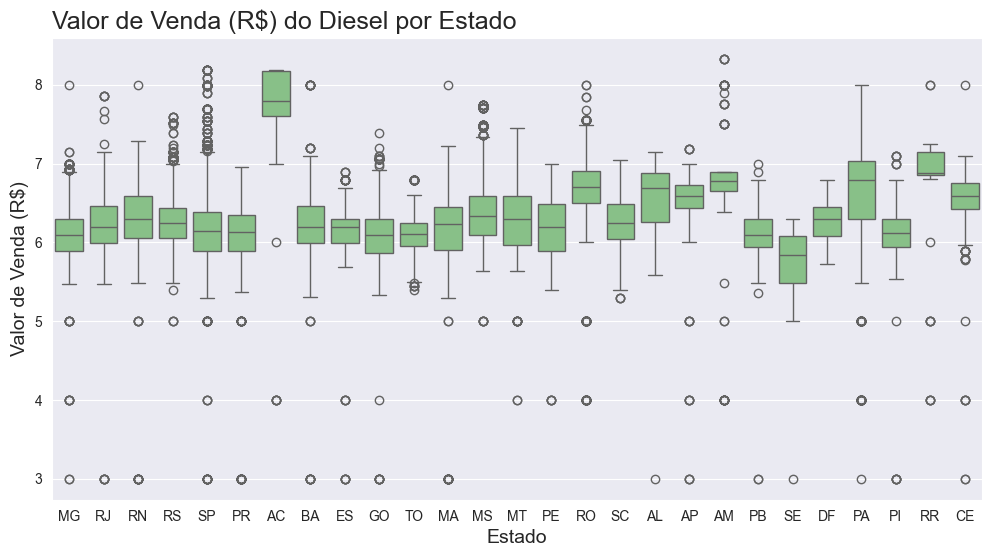

In [69]:
plotar_boxplot_V2('Valor de Venda (R$) do Diesel por Estado',
                  'Estado',
                  'Valor de Venda (R$)',
                  'estado',
                  'valor_venda',
                  diesel)

GNV

In [70]:
# estatistica básica de cada produto
print('GNV')
gnv.valor_venda.describe().round(2)

GNV


count    9525.00
mean        4.81
std         0.44
min         2.00
25%         4.49
50%         4.74
75%         4.99
max         6.49
Name: valor_venda, dtype: float64

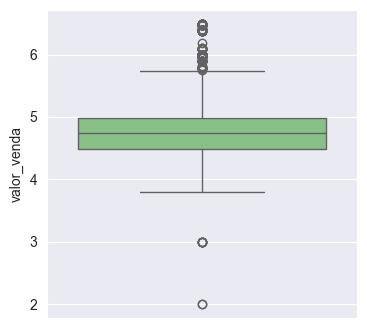

In [71]:
plotar_boxplot_geral('valor_venda', gnv)

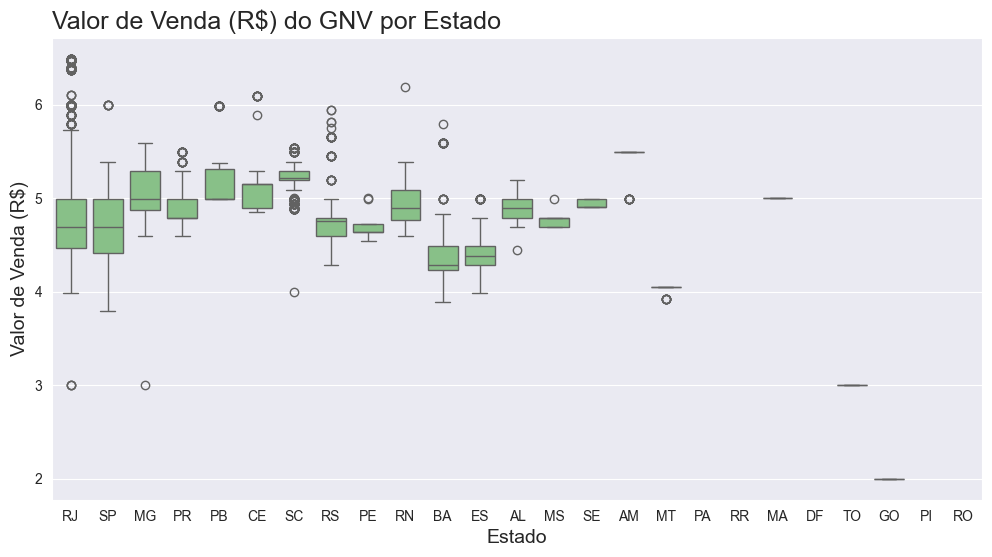

In [72]:
plotar_boxplot_V2('Valor de Venda (R$) do GNV por Estado',
                  'Estado',
                  'Valor de Venda (R$)',
                  'estado',
                  'valor_venda',
                  gnv)

Quantidade de Bandeiras distribuidoras

In [73]:
df_anp.head()

,data_coleta,regiao,estado,municipio,bandeira,produto,valor_venda,ano,mes
0,2025-01-01,NE,CE,SOBRAL,RAIZEN,GASOLINA,6.29,2025,1
1,2025-01-01,NE,CE,SOBRAL,RAIZEN,GASOLINA ADITIVADA,6.49,2025,1
2,2025-01-01,NE,CE,SOBRAL,RAIZEN,DIESEL S10,6.19,2025,1
3,2025-01-01,NE,CE,SOBRAL,RAIZEN,ETANOL,5.19,2025,1
4,2025-01-01,NE,CE,SOBRAL,RAIZEN,GASOLINA,6.53,2025,1


In [74]:
df_anp['bandeira'].nunique()

79

In [75]:
df_anp['bandeira'].unique()

array(['RAIZEN', 'VIBRA', 'IPIRANGA', 'BRANCA', 'ALE', 'TOTALENERGIES',
       'SABBÁ', 'LARCO', 'TAURUS', 'PETROBAHIA', 'STANG', 'RODOIL',
       'RAIZEN MIME', "ATEM' S", 'SP', 'POTENCIAL', 'CHARRUA', 'MAXSUL',
       'DIBRAPE', 'ATLÂNTICA', 'MASUT DISTRIBUIDORA', 'EQUADOR',
       'RIO BRANCO', 'CIAPETRO', 'D`MAIS', 'ROYAL FIC',
       'SETTA DISTRIBUIDORA', 'DISLUB', 'SANTA LUCIA', 'IDAZA', 'TEMAPE',
       'RZD DISTRIBUIDORA', 'TDC DISTRIBUIDORA', 'WATT', 'PELIKANO',
       'FEDERAL ENERGIA', 'FAN', 'ESTRADA', 'WALENDOWSKY',
       'PETROX DISTRIBUIDORA', 'PETROBRASIL', 'SIM DISTRIBUIDOR',
       'PETROSERRA', 'RDP ENERGIA', 'ON PETRO', 'AMERICANOIL',
       'VIBRA ENERGIA', 'ALESAT', 'REJAILE', 'SIMARELLI', 'UNI',
       'SUL COMBUSTÍVEIS', 'TORRAO', 'AIR BP', 'MONTEPETRO', 'SMALL',
       'PETROBRAS DISTRIBUIDORA S.A.', 'HORA', 'TOTAL BRASIL', 'PODIUM',
       'RUFF C.J.', 'FEDERAL', 'TOBRAS', 'GRAN PETRO', 'DINAMO',
       'RM PETROLEO', 'ACOL', 'SAARA', 'PETROLUZ', 'PR DISTRIB

In [89]:
bandeiras_estado = df_anp_bandeira_estado.groupby('estado').bandeira.nunique().reset_index()

In [90]:
bandeiras_estado

,estado,bandeira
0,AC,11
1,AL,13
2,AM,11
3,AP,5
4,BA,15
5,CE,15
6,DF,10
7,ES,9
8,GO,19
9,MA,14


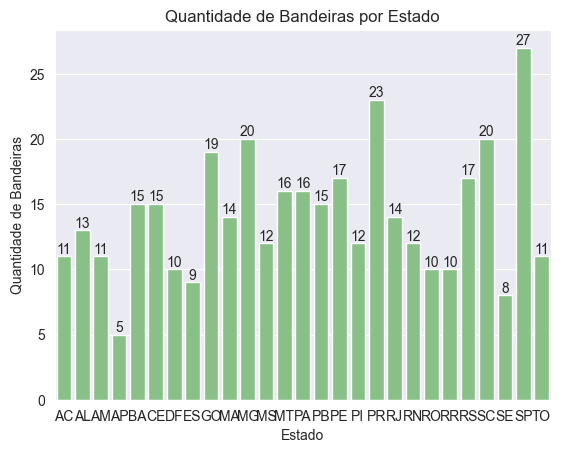

In [91]:
sns.barplot(x='estado', y='bandeira', data=bandeiras_estado)
plt.title('Quantidade de Bandeiras por Estado')
plt.xlabel('Estado')
plt.ylabel('Quantidade de Bandeiras')

for index, row in bandeiras_estado.iterrows():
  plt.annotate(row['bandeira'], xy=(index, row['bandeira']), ha='center', va='bottom')

plt.show()